In [28]:
# library(cowplot)
library(data.table)
library(dplyr)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [18]:
cols_df = as.data.frame(fread('/directflow/SCCGGroupShare/projects/blabow/tenk10k_phase1/plotting_notebooks/overview_figures/manuscript_figures/colour_palette_table.tsv'))
head(cols_df)

,wg2_scpred_prediction,color_material,color_biorender1,color_biorender2,color,color_major_cell_type,color_major_cell_type_light,color_major_cell_type_light2,cell_type,major_cell_type
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,CD4_TCM,#0C46A0FF,#AB728A,#9C85C3,#311A92FF,#7E57C1FF,#ECE6F6FF,#D1C4E9FF,CD4 TCM,CD4 T
2,CD4_Naive,#1976D2FF,#83576A,#605278,#512CA7FF,#7E57C1FF,#ECE6F6FF,#D1C4E9FF,CD4 Naive,CD4 T
3,CD4_TEM,#2096F2FF,#C4839E,#8773A8,#6639B7FF,#7E57C1FF,#ECE6F6FF,#D1C4E9FF,CD4 TEM,CD4 T
4,CD4_CTL,#64B4F6FF,#DA91B0,#B197DD,#9474CCFF,#7E57C1FF,#ECE6F6FF,#D1C4E9FF,CD4 CTL,CD4 T
5,Treg,#90CAF8FF,#F4BFE0,#DFB4EC,#B29DDAFF,#7E57C1FF,#ECE6F6FF,#D1C4E9FF,Treg,CD4 T
6,CD4_Proliferating,#BADEFAFF,#DA91B0,#D4ACE1,#D1C4E9FF,#7E57C1FF,#ECE6F6FF,#D1C4E9FF,CD4 Proliferating,CD4 T


In [19]:
anno_folder = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/review_files/rv_anno_test_results/functional/'

In [20]:
# list.files(anno_folder)
celltypes = gsub('summary_stats_','',gsub('_all_cis_rv_set_test_results.tsv','',list.files(anno_folder)))
length(celltypes)
celltypes

[1] 28

[1] "ASDC"              "B_intermediate"    "B_memory"         
 [4] "B_naive"           "CD14_Mono"         "CD16_Mono"        
 [7] "CD4_CTL"           "CD4_Naive"         "CD4_Proliferating"
[10] "CD4_TCM"           "CD4_TEM"           "CD8_Naive"        
[13] "CD8_Proliferating" "CD8_TCM"           "CD8_TEM"          
[16] "cDC1"              "cDC2"              "dnT"              
[19] "gdT"               "HSPC"              "ILC"              
[22] "MAIT"              "NK"                "NK_CD56bright"    
[25] "NK_Proliferating"  "pDC"               "Plasmablast"      
[28] "Treg"

In [21]:
no_anno_folder = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/eqtl_results/saige_qtl/december24_freeze/'

In [22]:
disease_genes_dir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/review_files/disease_gene_lists/'
list.files(disease_genes_dir)

[1] "gene_fulltable.txt" "Incidentalome.tsv"  "Mendeliome.tsv"

In [23]:
df_genes1 = as.data.frame(fread(paste0(disease_genes_dir,'Mendeliome.tsv')))
# colnames(df_genes1)
head(df_genes1,2)
genes1 = unique(df_genes1[['EnsemblId(GRch38)']])
length(genes1)
head(genes1)

,Entity Name,Entity type,Gene Symbol,Sources(; separated),Level4,Level3,Level2,Model_Of_Inheritance,Phenotypes,Omim,⋯,Position GRCh38 Start,Position GRCh38 End,STR Repeated Sequence,STR Normal Repeats,STR Pathogenic Repeats,Region Haploinsufficiency Score,Region Triplosensitivity Score,Region Required Overlap Percentage,Region Variant Type,Region Verbose Name
,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<chr>,<chr>,<lgl>,⋯,<int>,<int>,<chr>,<int>,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,AAAS,gene,AAAS,Expert list;Expert Review Green;Victorian Clinical Genetics Services,Mendeliome,NA,NA,"BIALLELIC, autosomal or pseudoautosomal","Achalasia-addisonianism-alacrimia syndrome, MIM#231550",NA,⋯,NA,NA,,NA,NA,NA,NA,NA,NA,NA
2,AAGAB,gene,AAGAB,Expert Review Green;Victorian Clinical Genetics Services,Mendeliome,NA,NA,"MONOALLELIC, autosomal or pseudoautosomal, NOT imprinted","Keratoderma, palmoplantar, punctate type IA (MIM#148600)",NA,⋯,NA,NA,,NA,NA,NA,NA,NA,NA,NA


[1] 4172

[1] "ENSG00000094914" "ENSG00000103591" "ENSG00000090861" "ENSG00000124608"
[5] "ENSG00000183044" "ENSG00000165029"

In [24]:
df_genes2 = as.data.frame(fread(paste0(disease_genes_dir,'Incidentalome.tsv')))
# colnames(df_genes2)
head(df_genes2,2)
genes2 = unique(df_genes2[['EnsemblId(GRch38)']])
length(genes2)
head(genes2)

,Entity Name,Entity type,Gene Symbol,Sources(; separated),Level4,Level3,Level2,Model_Of_Inheritance,Phenotypes,Omim,⋯,Position GRCh38 Start,Position GRCh38 End,STR Repeated Sequence,STR Normal Repeats,STR Pathogenic Repeats,Region Haploinsufficiency Score,Region Triplosensitivity Score,Region Required Overlap Percentage,Region Variant Type,Region Verbose Name
,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<chr>,<chr>,<lgl>,⋯,<int>,<int>,<chr>,<int>,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,ACTA2,gene,ACTA2,Expert Review Green;Victorian Clinical Genetics Services,Incidentalome,NA,NA,"MONOALLELIC, autosomal or pseudoautosomal, NOT imprinted","Aortic aneurysm, familial thoracic 6, MIM# 611788;Multisystemic smooth muscle dysfunction syndrome, MIM# 613834",NA,⋯,NA,NA,,NA,NA,NA,NA,NA,NA,NA
2,ANXA11,gene,ANXA11,Expert list;Expert Review Green,Incidentalome,NA,NA,"MONOALLELIC, autosomal or pseudoautosomal, NOT imprinted","Inclusion body myopathy and brain white matter abnormalities, MIM# 619733;Amyotrophic lateral sclerosis 23, MIM# 617839",NA,⋯,NA,NA,,NA,NA,NA,NA,NA,NA,NA


[1] 119

[1] "ENSG00000107796" "ENSG00000122359" "ENSG00000134982" "ENSG00000084674"
[5] "ENSG00000130203" "ENSG00000142192"

In [38]:
df_genes3 = as.data.frame(fread(paste0(disease_genes_dir,'gene_fulltable.txt')))
colnames(df_genes3)
df_genes3 = df_genes3[as.numeric(df_genes3[['P-value']])<5e-8,]
# head(df_genes3,1)
genes3 = unique(df_genes3[['Ensembl ID']])
length(genes3)
head(genes3)

Warning message in fread(paste0(disease_genes_dir, "gene_fulltable.txt")):
“Found and resolved improper quoting out-of-sample. First healed line 40340: <<MC1R	ENSG00000258839	protein_coding	16	chr16:89912119-89920973	melanocortin 1 receptor	MSH-R	This intronless gene encodes the receptor protein for melanocyte-stimulating hormone (MSH). The encoded protein, a seven pass transmembrane G protein coupled receptor, controls melanogenesis. Two types of melanin exist: red pheomelanin and black eumelanin. Gene mutations that lead to a loss in function are associated with increased pheomelanin production, which leads to lighter skin and hair color. Eumel>>. If the fields are not quoted (e.g. field separator does not appear within any field), try quote="" to avoid this warning.”


[1] "Gene Symbol"       "Ensembl ID"        "Gene Type"        
 [4] "CHR"               "Location"          "Gene full name"   
 [7] "Gene synonym"      "Gene summary"      "RID"              
[10] "Reported Trait"    "Trait Label"       "Trait Ontology id"
[13] "EFO description"   "EFO synonym"       "EFO Tree"         
[16] "P-value"           "Method/Software"   "PMID"             
[19] "Title"             "Authors"           "Citation"         
[22] "First Author"      "Journal/Book"      "Publication Year" 
[25] "Create Date"       "PMCID"             "NIHMS ID"         
[28] "DOI"

Warning message in `[.data.frame`(df_genes3, as.numeric(df_genes3[["P-value"]]) < :
“NAs introduced by coercion”


[1] 5209

[1] "ENSG00000148584" "ENSG00000175899" "ENSG00000166535" "ENSG00000114771"
[5] "ENSG00000109576" "ENSG00000115977"

In [42]:
all_disease_genes = unique(c(genes1,genes2))
# all_disease_genes = unique(c(genes1,genes2,genes3))
length(all_disease_genes)

[1] 4290

Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”


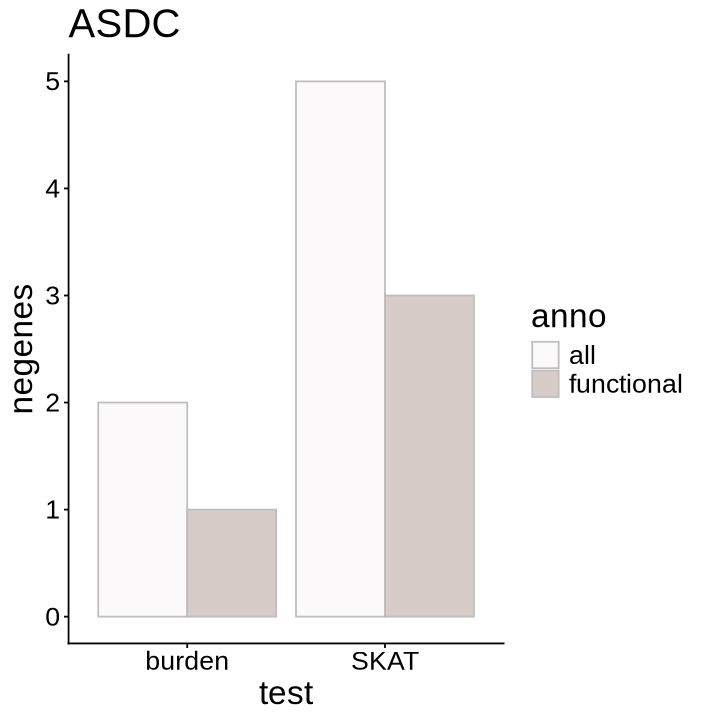

Warning message:
“Using alpha for a discrete variable is not advised.”


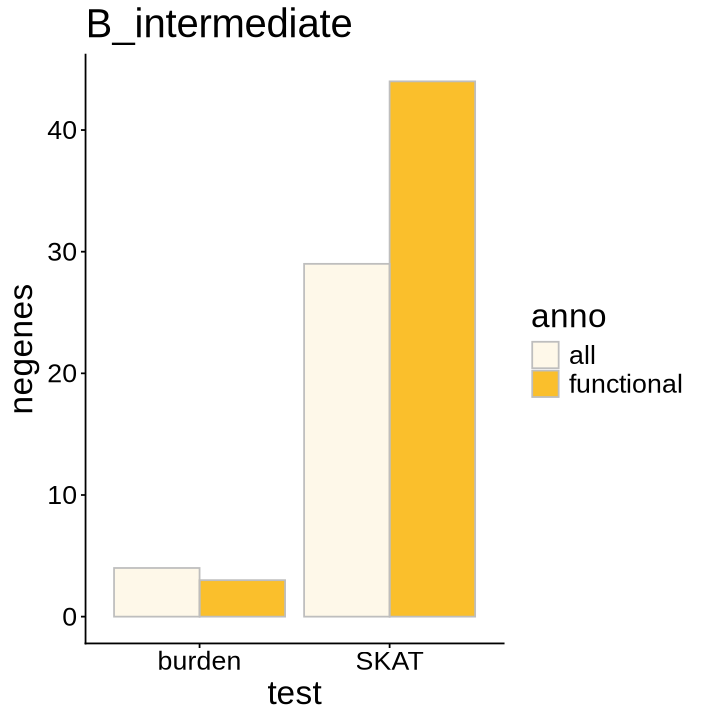

Warning message:
“Using alpha for a discrete variable is not advised.”


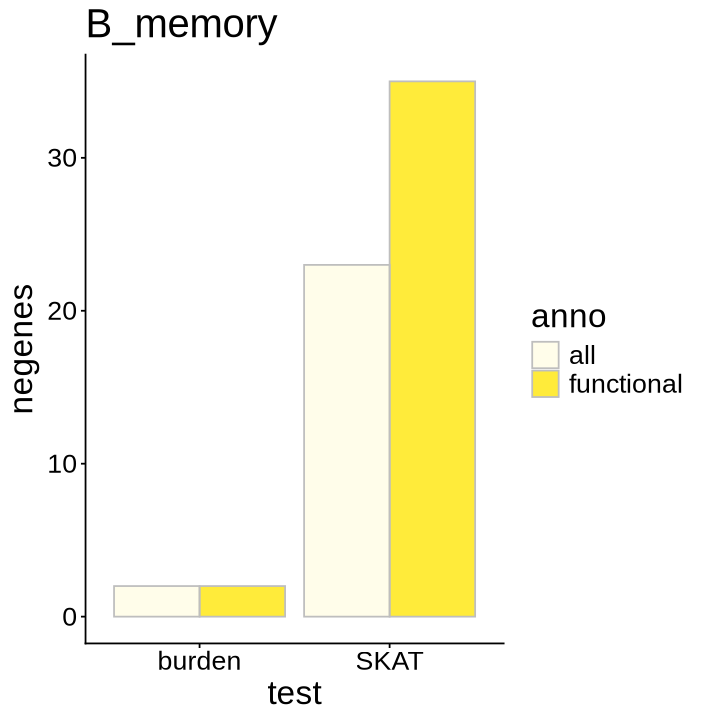

Warning message:
“Using alpha for a discrete variable is not advised.”


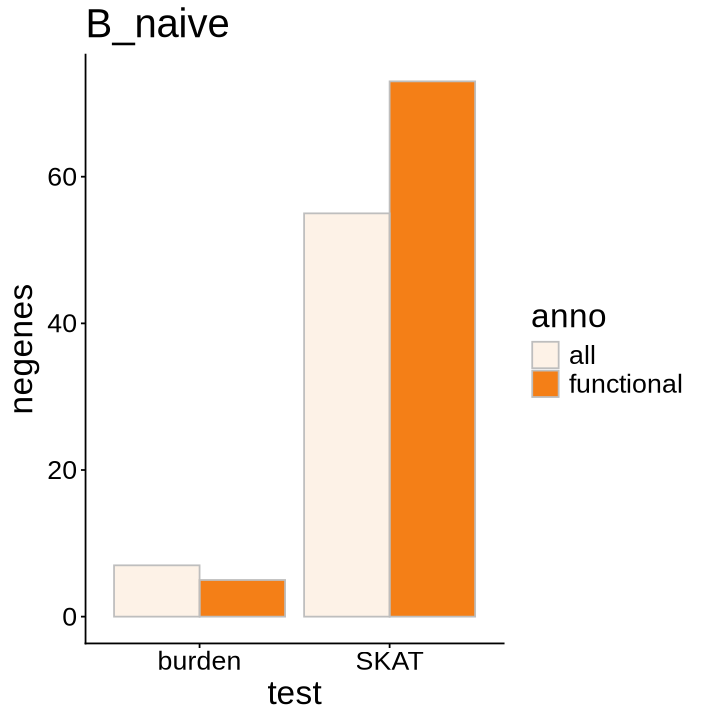

Warning message:
“Using alpha for a discrete variable is not advised.”


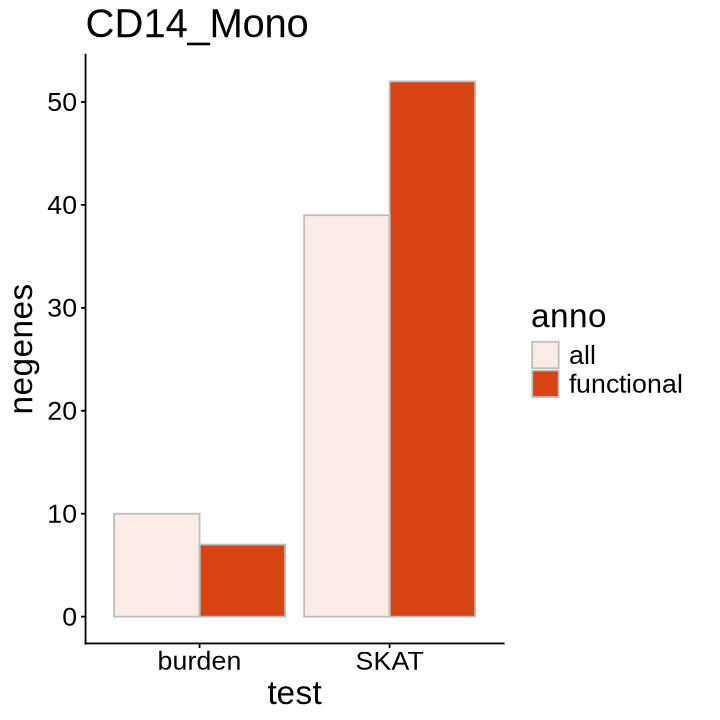

Warning message:
“Using alpha for a discrete variable is not advised.”


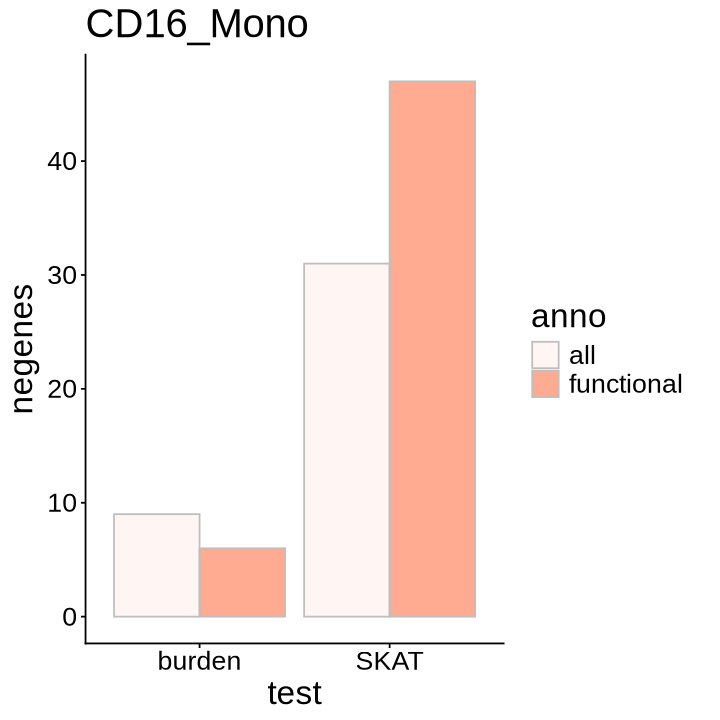

Warning message:
“Using alpha for a discrete variable is not advised.”


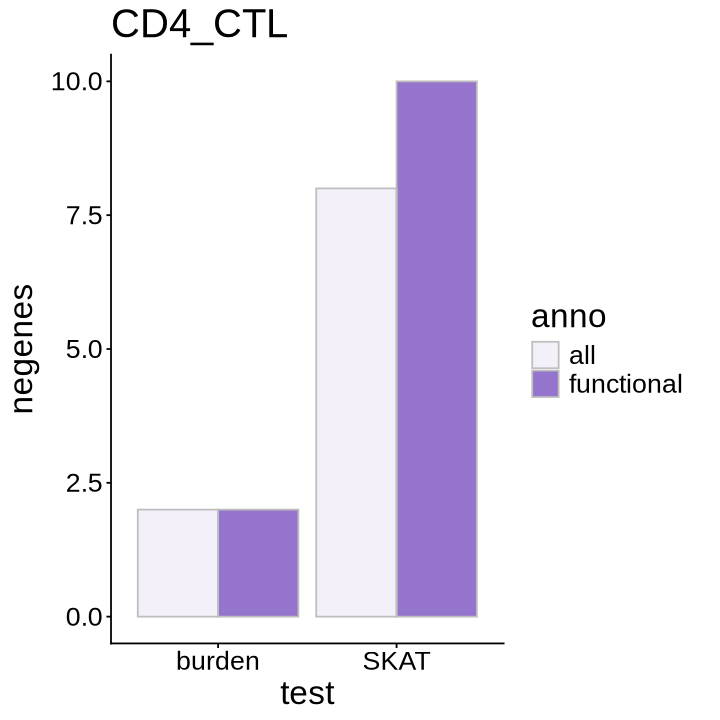

Warning message:
“Using alpha for a discrete variable is not advised.”


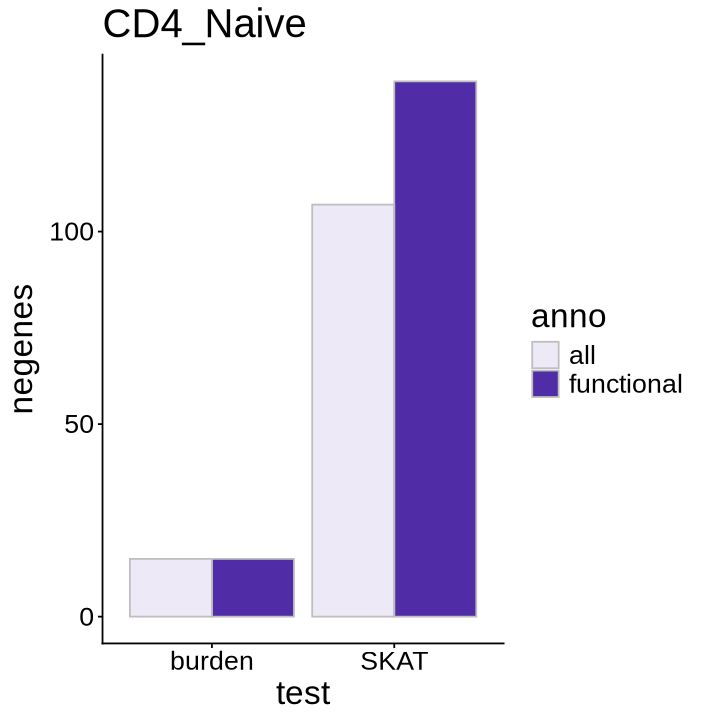

Warning message:
“Using alpha for a discrete variable is not advised.”


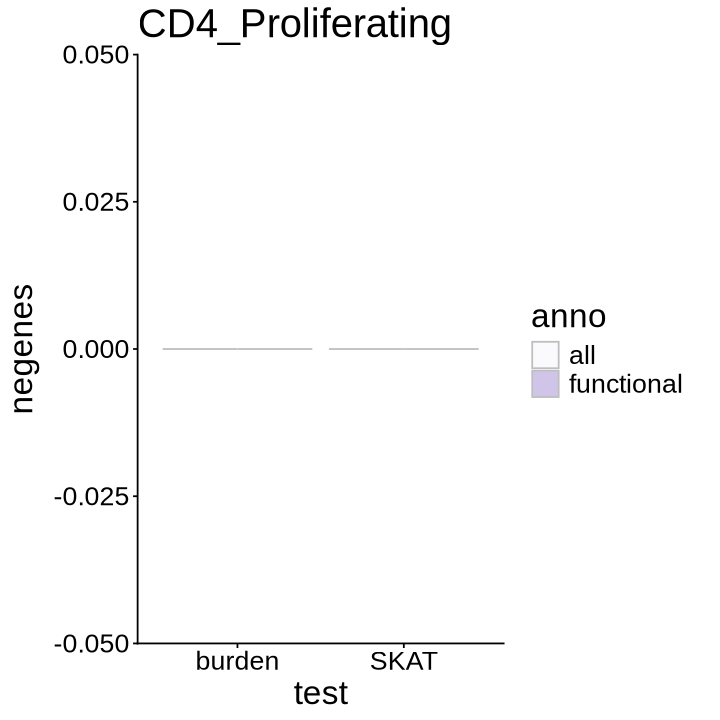

Warning message:
“Using alpha for a discrete variable is not advised.”


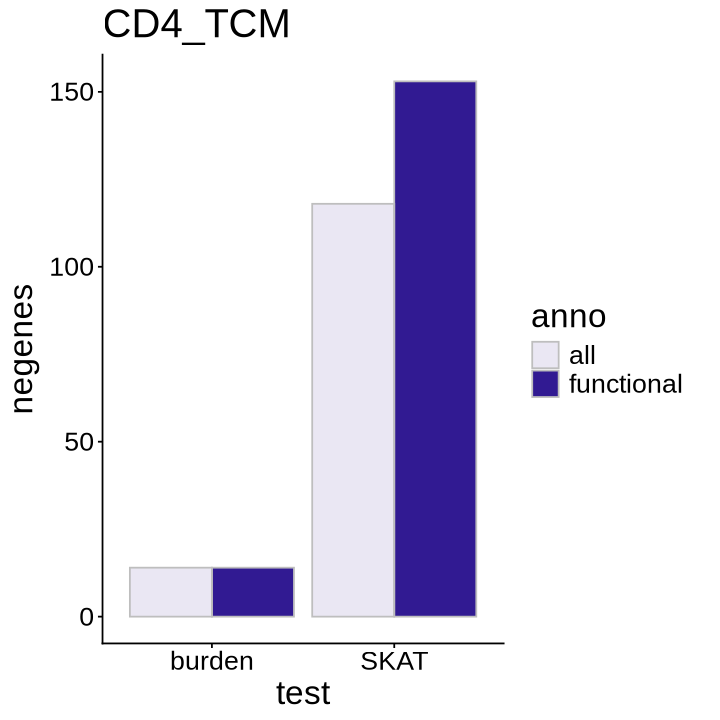

Warning message:
“Using alpha for a discrete variable is not advised.”


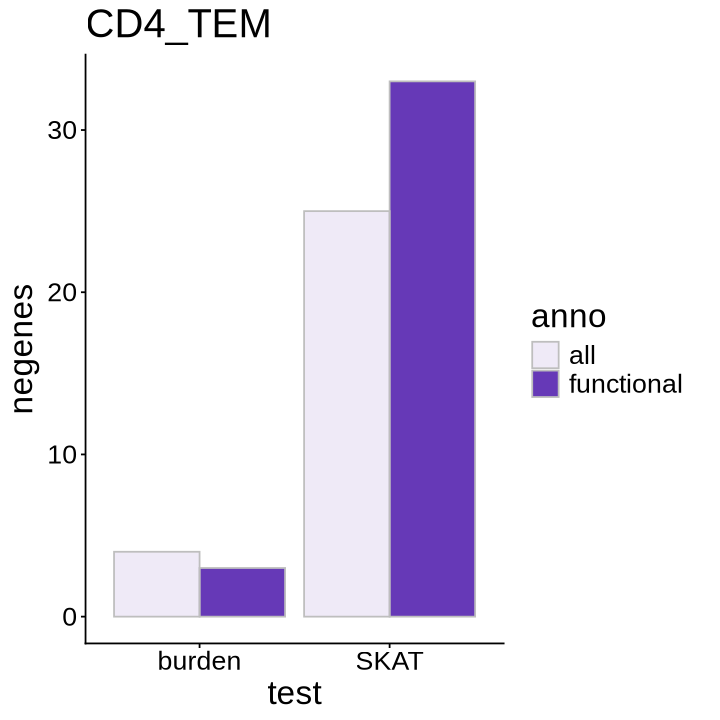

Warning message:
“Using alpha for a discrete variable is not advised.”


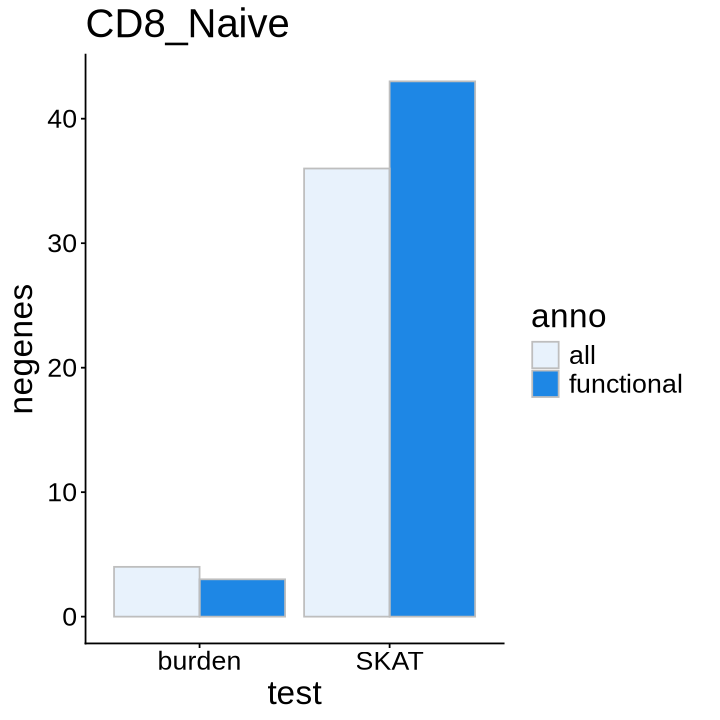

Warning message:
“Using alpha for a discrete variable is not advised.”


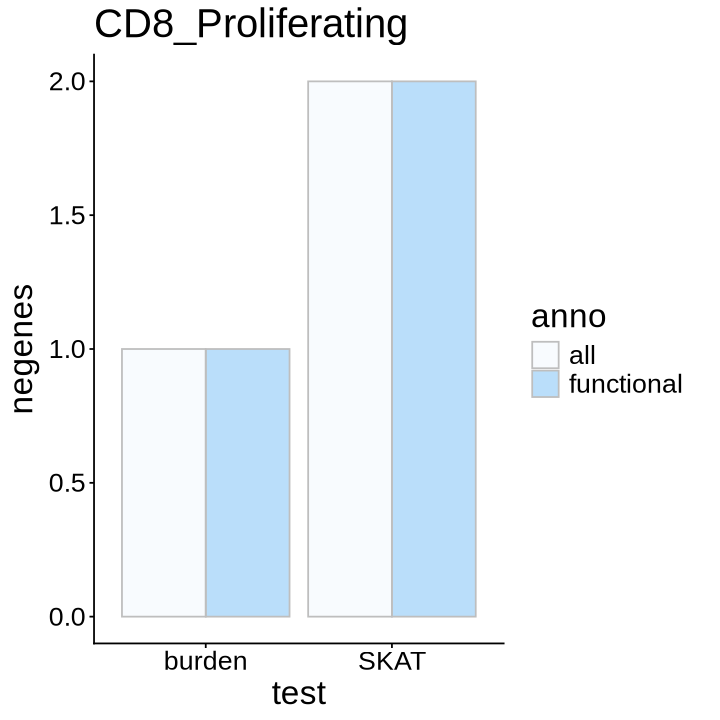

Warning message:
“Using alpha for a discrete variable is not advised.”


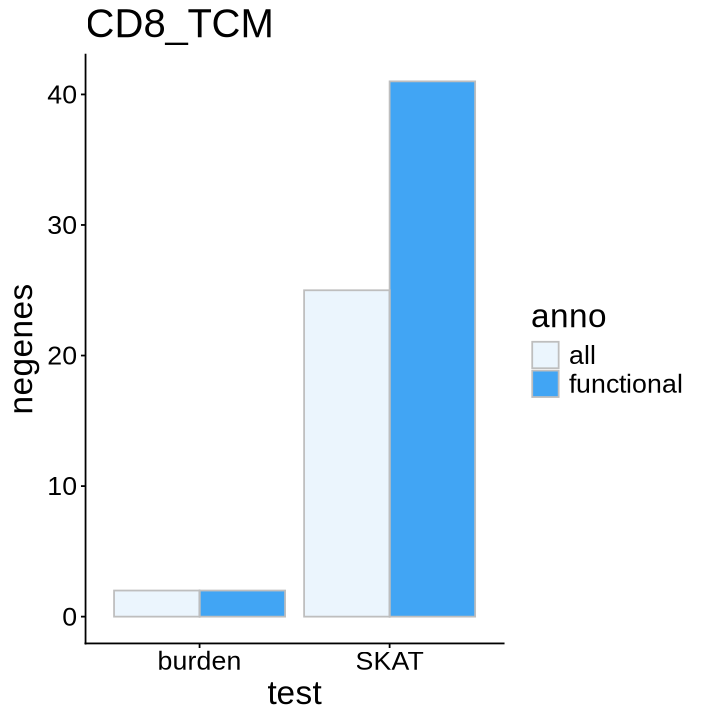

Warning message:
“Using alpha for a discrete variable is not advised.”


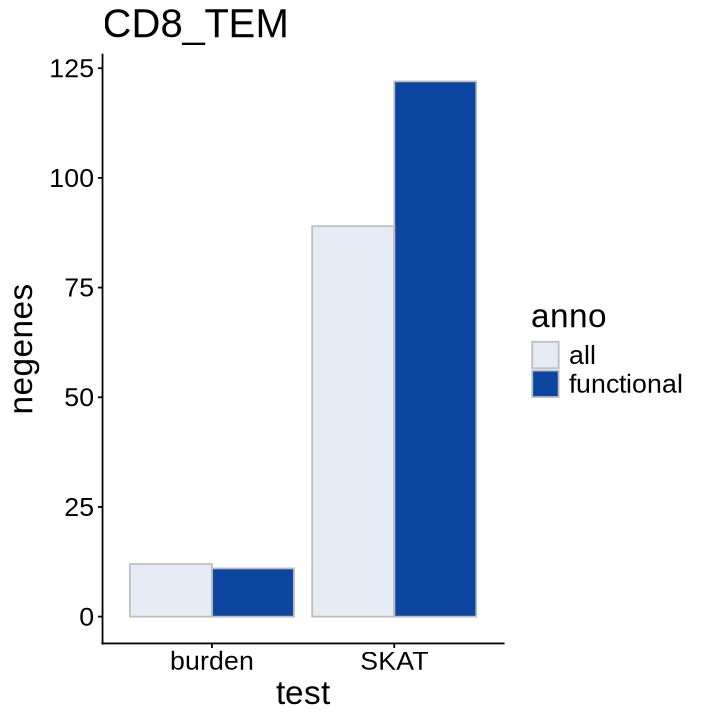

Warning message:
“Using alpha for a discrete variable is not advised.”


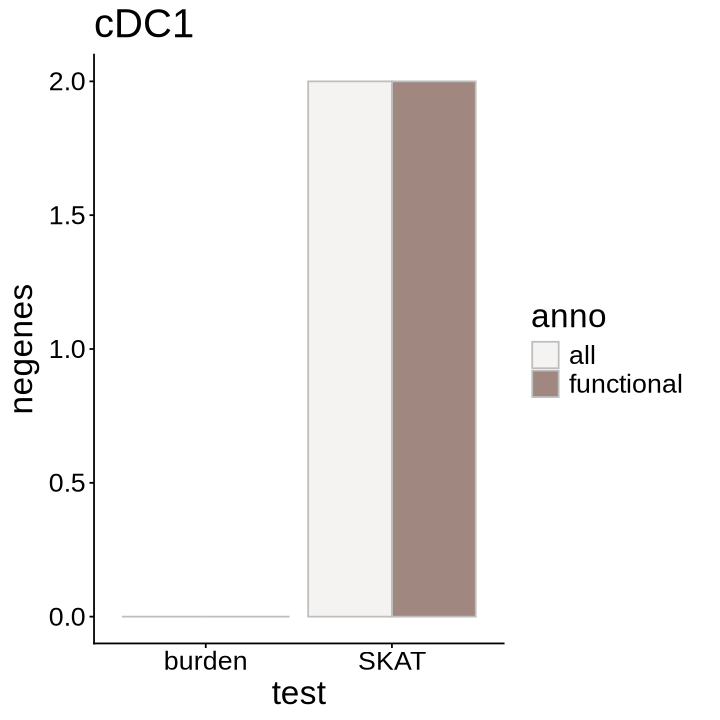

Warning message:
“Using alpha for a discrete variable is not advised.”


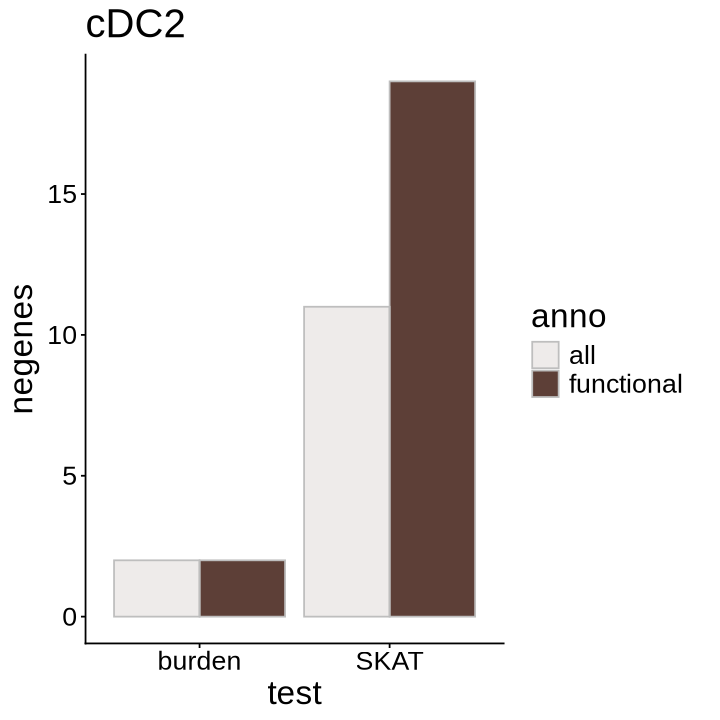

Warning message:
“Using alpha for a discrete variable is not advised.”


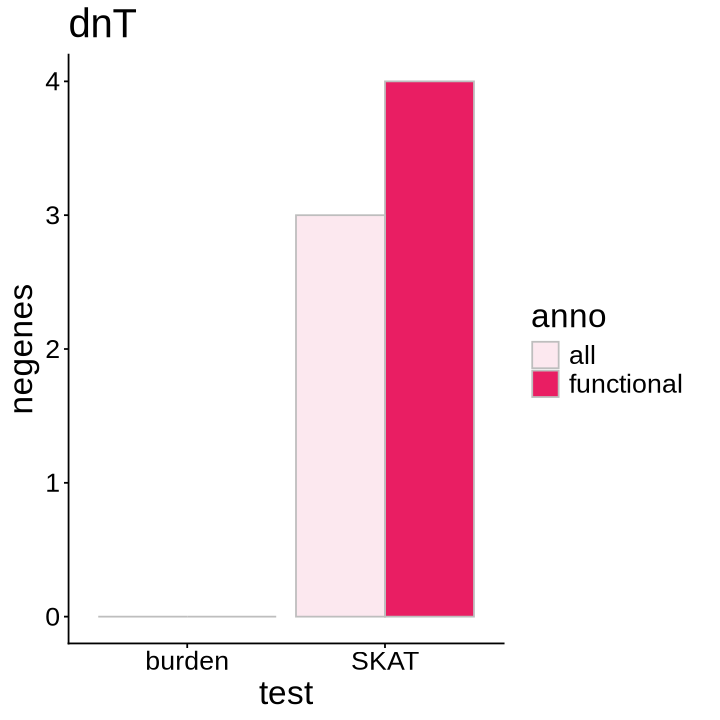

Warning message:
“Using alpha for a discrete variable is not advised.”


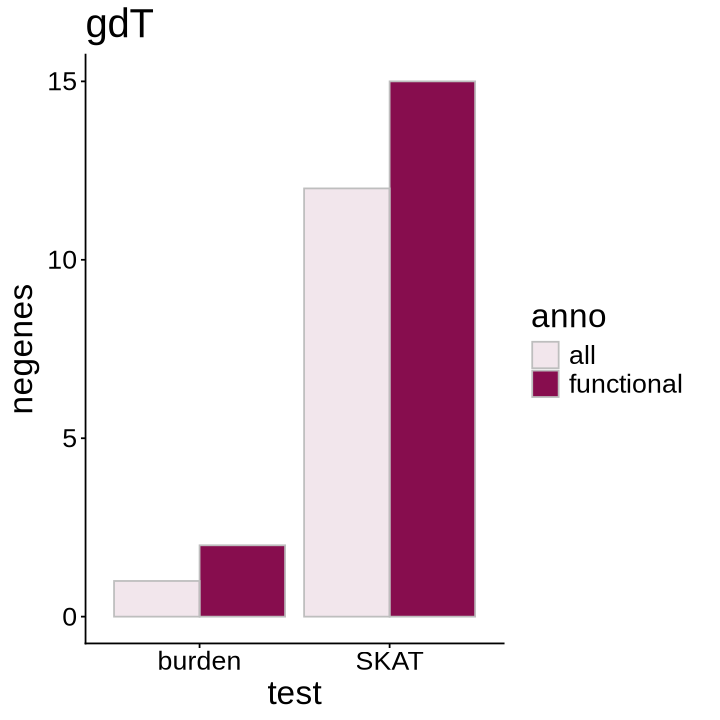

Warning message:
“Using alpha for a discrete variable is not advised.”


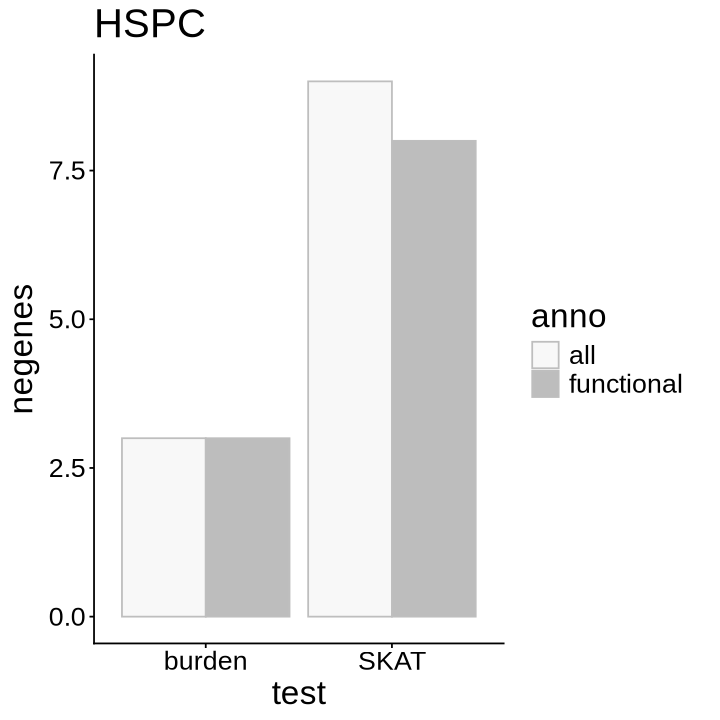

Warning message:
“Using alpha for a discrete variable is not advised.”


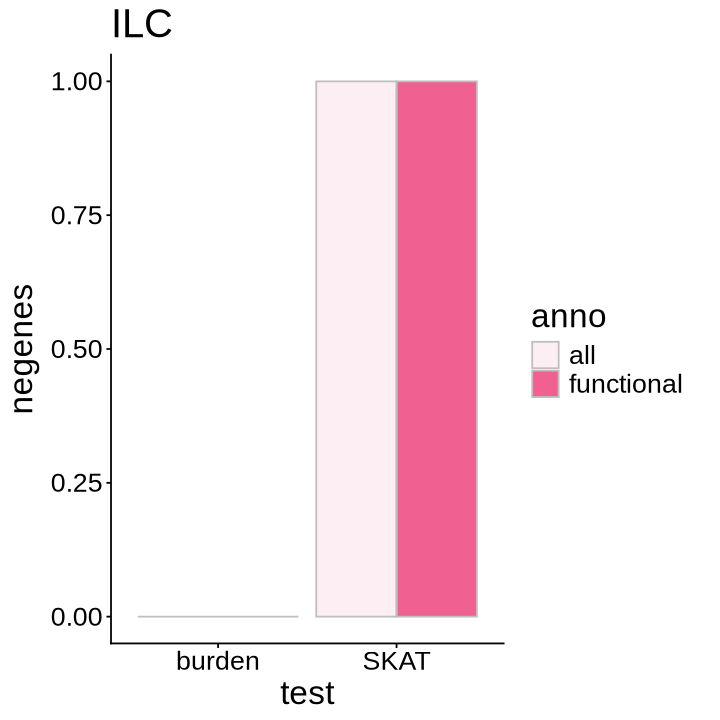

Warning message:
“Using alpha for a discrete variable is not advised.”


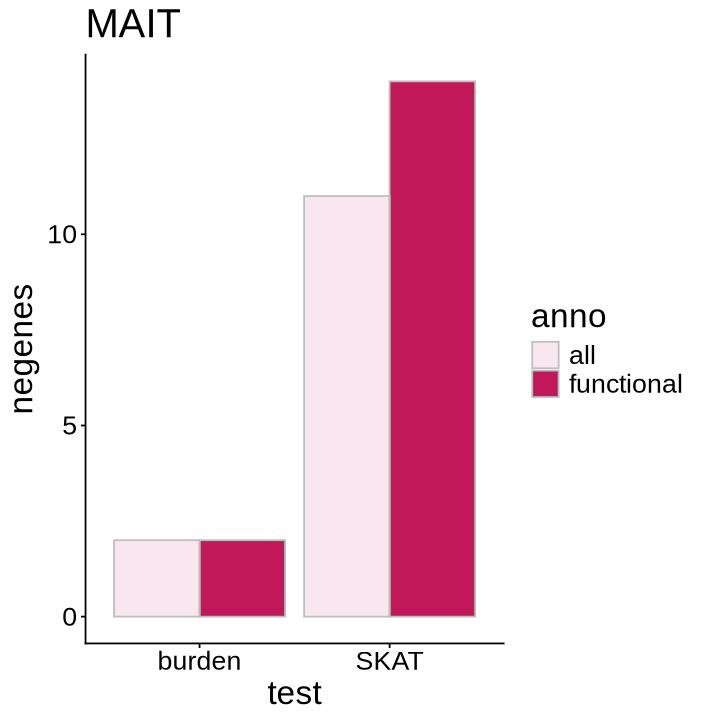

Warning message:
“Using alpha for a discrete variable is not advised.”


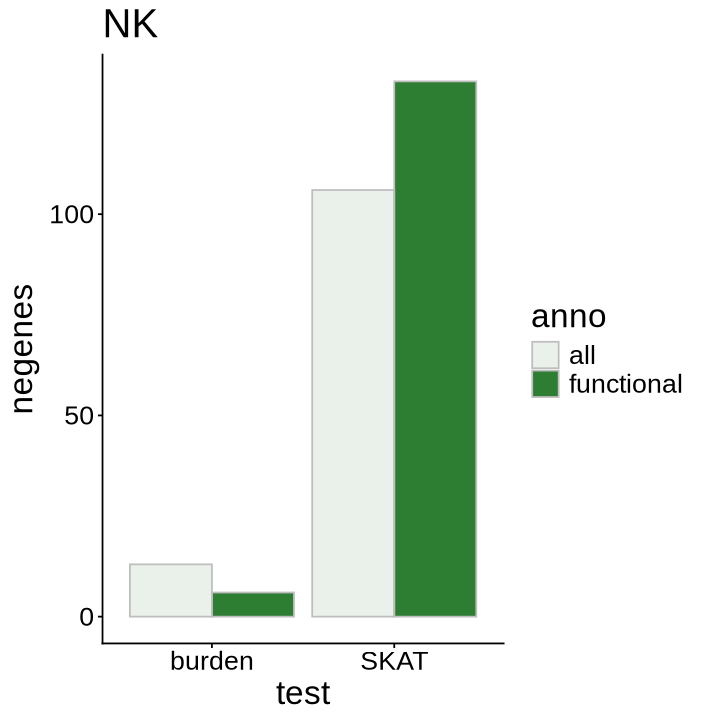

Warning message:
“Using alpha for a discrete variable is not advised.”


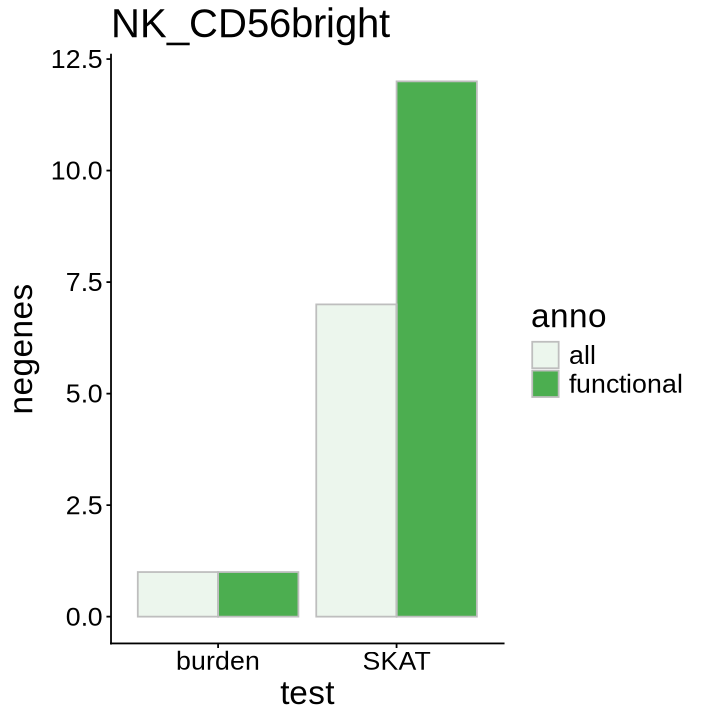

Warning message:
“Using alpha for a discrete variable is not advised.”


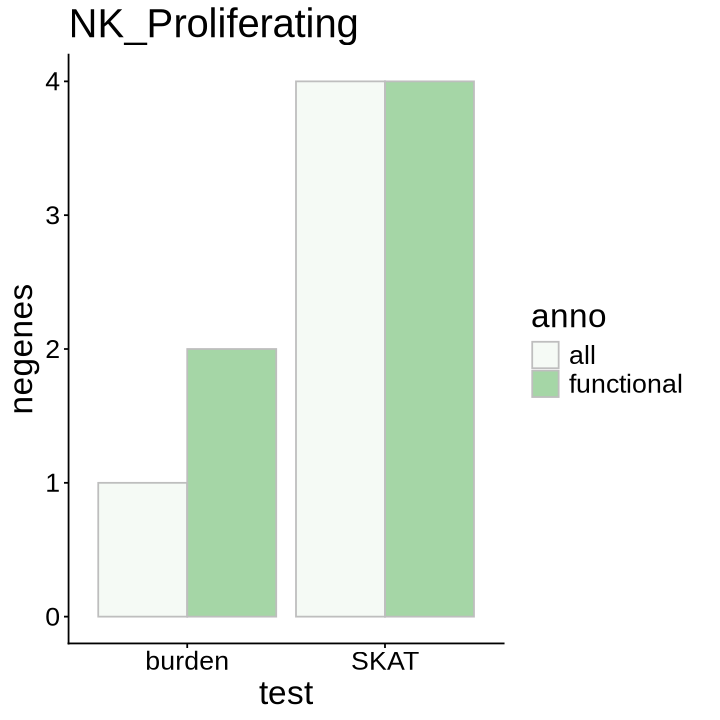

Warning message:
“Using alpha for a discrete variable is not advised.”


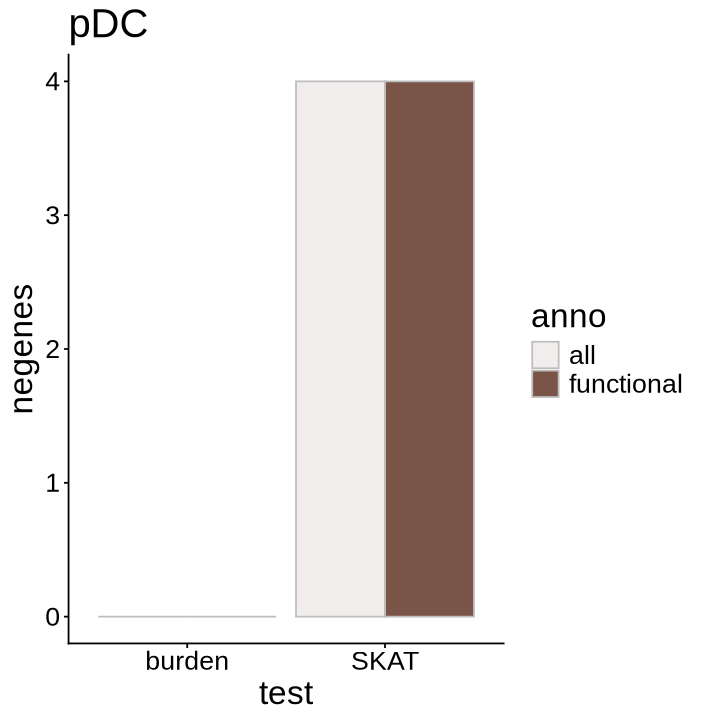

Warning message:
“Using alpha for a discrete variable is not advised.”


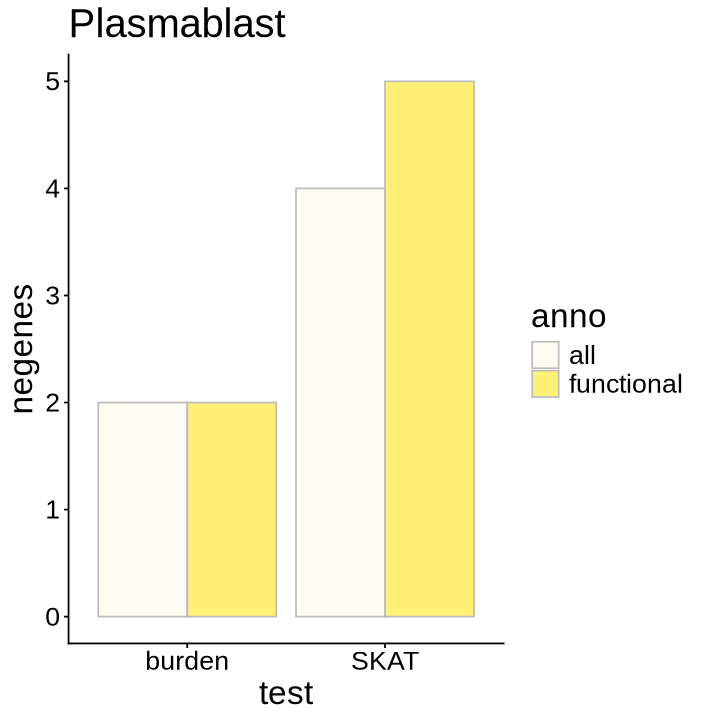

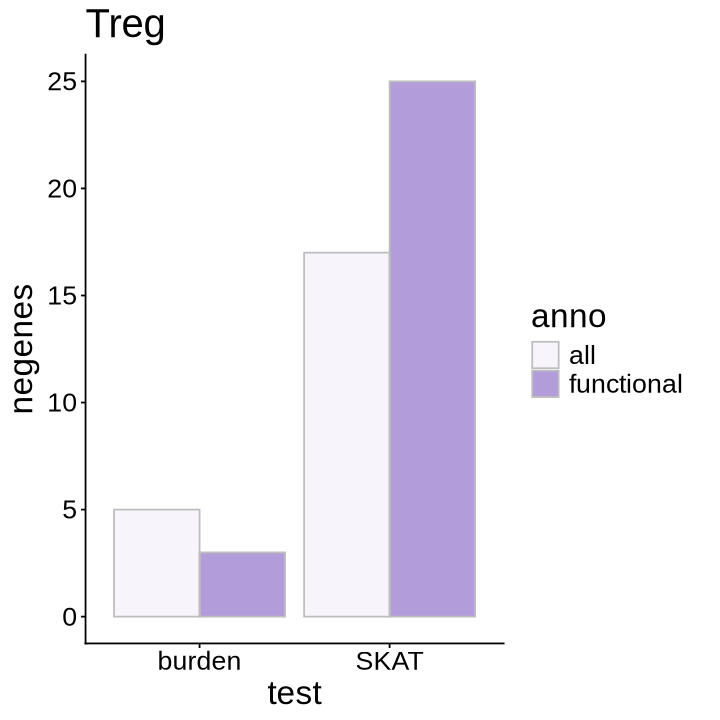

In [43]:
options(repr.plot.width = 6, repr.plot.height = 6)
for (celltype in celltypes){
    no_anno_file = paste0(no_anno_folder,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    anno_file = paste0(anno_folder,celltype,'_all_cis_rv_set_test_results.tsv')
    col = cols_df[cols_df$wg2_scpred_prediction == celltype,]$color
    df0 = as.data.frame(fread(no_anno_file))
    df0$gene = df0$Region
    df1 = as.data.frame(fread(anno_file))
    df1$gene = gsub('_functional','',df1$Region)
    df00 = df0[df0$Weight == 'dTSS',]
    df00 <- df00[rowSums(is.na(df00)) != ncol(df00), ]
    df10 = df1[df1$Weight == 'WEIGHT',]
    df10 <- df10[rowSums(is.na(df10)) != ncol(df10), ]
    df10 = df10[df10$Number_rare>200,]
    df2 = inner_join(df00,df10, by='gene', suffix=c('.no_anno','.anno'))
    df2 = df2[df2$gene %in% all_disease_genes,]
    df_to_plot = data.frame(negenes = c(nrow(df2[df2$Pvalue_Burden.anno<1e-6,]),
                                    nrow(df2[df2$Pvalue_Burden.no_anno<1e-6,]),
                                    nrow(df2[df2$Pvalue_SKAT.anno<1e-6,]),
                                    nrow(df2[df2$Pvalue_SKAT.no_anno<1e-6,])),
                       test = c('burden','burden','SKAT','SKAT'),
                       anno = c('functional','all','functional','all'))
    p = ggplot(df_to_plot, aes(x=test, y=negenes, alpha=anno)) 
    p = p + geom_bar(stat='identity', position = 'dodge', fill=col, col='grey')
    p = p + theme_classic() + theme(text = element_text(size=20)) 
    print(p + ggtitle(celltype))
}